In [1]:
# ==========================================
# Section 1: Imports, Configuration & Random Seed
# ==========================================
import os, glob, re, html, copy, random, time 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
from torch.utils.data import DataLoader, Dataset
from torch.cuda.amp import autocast, GradScaler
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_cosine_schedule_with_warmup
from torch.optim import AdamW

# --- Import LoRA from PEFT ---
from peft import LoraConfig, get_peft_model, TaskType

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 0. Configuration and Random Seed Setup
# ==========================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"Random seed set to {seed}")

set_seed(42)

EVENT_WISE_DIR = '/kaggle/input/datasets/jieyang02/aa-nlp/aa - nlp/HumAID_data_event_wise'
EVENT_TYPE_DIR = '/kaggle/input/datasets/jieyang02/aa-nlp/aa - nlp/HumAID_data_event_type/event_type'

MODEL_NAME = 'answerdotai/ModernBERT-base'
BATCH_SIZE = 16 
ACCUMULATION_STEPS = 2   # Gradient accumulation, equivalent to real Batch Size = 16 * 2 = 32
MAX_LEN = 128
EPOCHS = 5               # Train the general model for 5 full epochs
PATIENCE = 2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Random seed set to 42


In [2]:
# ==========================================
# Section 2: Data Cleaning and DataLoaders
# ==========================================
def clean_tweet(text):
    if pd.isna(text): return ""
    text = html.unescape(str(text)).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\@\w+', '', text)
    
    # Disaster keyword de-biasing: Forces the model to learn contextual semantics 
    # rather than memorizing domain-specific disaster nouns
    disaster_keywords = ['earthquake', 'quake', 'fire', 'wildfire', 'flood', 'flooding', 'hurricane', 'storm', 'cyclone', 'typhoon']
    for kw in disaster_keywords:
        text = text.replace(kw, ' disaster ')
        
    text = text.replace('#', '')
    text = re.sub(r'(.)\1+', r'\1\1', text) 
    return " ".join(text.split())

class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self): 
        return len(self.texts)
    
    def __getitem__(self, i):
        enc = self.tokenizer(
            str(self.texts[i]),
            add_special_tokens=True, 
            max_length=self.max_len, 
            padding='max_length',
            truncation=True, 
            return_tensors='pt'
        )
        return {
            'input_ids': enc['input_ids'].flatten(),
            'attention_mask': enc['attention_mask'].flatten(), 
            'labels': torch.tensor(self.labels[i], dtype=torch.long)
        }

class EarlyStoppingF1:
    def __init__(self, patience=2):
        self.patience = patience
        self.counter = 0
        self.best_f1 = -1.0
        self.early_stop = False
        self.best_model_state = None

    def __call__(self, current_f1, model):
        if current_f1 > self.best_f1:
            self.best_f1 = current_f1
            # Save state dict to CPU memory to prevent GPU VRAM leakage
            self.best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            print(f"     --> [Best F1: {self.best_f1:.4f}] Weights Saved.")
        else:
            self.counter += 1
            if self.counter >= self.patience: 
                self.early_stop = True

In [3]:
# ==========================================
# Section 3: Build Dictionary and Merge 100% Data
# ==========================================
print("\nBuilding Dictionary...")
tweet_text_dict = {}
for file_path in glob.glob(os.path.join(EVENT_WISE_DIR, '**/*.tsv'), recursive=True):
    if os.path.basename(file_path).startswith('._'): continue
    try:
        df_temp = pd.read_csv(file_path, sep='\t', dtype={'tweet_id': str})
        for _, row in df_temp.iterrows():
            if pd.notna(row['tweet_id']):
                tweet_text_dict[str(row['tweet_id'])] = clean_tweet(row['tweet_text'])
    except: pass

ALL_TYPES = ['earthquake', 'fire', 'flood', 'hurricane']
data_dict = {t: {'train': None, 'dev': None, 'test': None} for t in ALL_TYPES}

def load_split(d, s):
    path = os.path.join(EVENT_TYPE_DIR, f'{d}_{s}.tsv')
    if not os.path.exists(path): return pd.DataFrame()
    df = pd.read_csv(path, sep='\t', dtype={'tweet_id': str})
    df['tweet_text'] = df['tweet_id'].map(tweet_text_dict)
    return df.dropna(subset=['tweet_text', 'class_label'])

all_labels = []
train_dfs = []
test_dfs = []

for d in ALL_TYPES:
    for s in ['train', 'dev', 'test']:
        df = load_split(d, s)
        data_dict[d][s] = df
        if not df.empty: 
            all_labels.extend(df['class_label'].tolist())
            
    # Combine ALL Train and Dev sets into one massive training set
    if not data_dict[d]['train'].empty: train_dfs.append(data_dict[d]['train'])
    if not data_dict[d]['dev'].empty: train_dfs.append(data_dict[d]['dev'])
    
    # Combine ALL Test sets to monitor final generalization
    if not data_dict[d]['test'].empty: test_dfs.append(data_dict[d]['test'])

# Create Ultimate DataFrames
general_train_df = pd.concat(train_dfs, ignore_index=True)
general_test_df = pd.concat(test_dfs, ignore_index=True)

print(f"\n[GENERAL MODEL DATA]")
print(f"Total Combined Train Size (All Train + Dev): {len(general_train_df)}")
print(f"Total Combined Test Size (All Test): {len(general_test_df)}")

# Global Label Encoder (11-Class Configuration)
label_encoder = LabelEncoder().fit(all_labels)
num_labels = len(label_encoder.classes_)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


Building Dictionary...

[GENERAL MODEL DATA]
Total Combined Train Size (All Train + Dev): 61324
Total Combined Test Size (All Test): 15160


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

In [4]:
# ==========================================
# Section 4: Training the General Model
# ==========================================
print("\n" + "="*80)
print("STARTING TRAINING: ULTIMATE GENERAL MODEL (ModernBERT + LoRA)")
print("="*80)

total_experiment_start_time = time.time() 

# Encode labels
y_train_idx = label_encoder.transform(general_train_df['class_label'])
y_test_idx = label_encoder.transform(general_test_df['class_label'])

# --- Handle Extreme Class Imbalance via Clipped Weights ---
class_counts = np.bincount(y_train_idx, minlength=num_labels)
class_counts = np.maximum(class_counts, 1) # Prevent division by zero
total_samples = len(y_train_idx)

raw_weights = total_samples / (num_labels * class_counts)
clipped_weights = np.clip(raw_weights, 1.0, 5.0)  
weights_tensor = torch.tensor(clipped_weights, dtype=torch.float).to(DEVICE)

loss_fn = torch.nn.CrossEntropyLoss(
    weight=weights_tensor, 
    label_smoothing=0.05 
)

train_loader = DataLoader(
    TweetDataset(general_train_df['tweet_text'].values, y_train_idx, tokenizer, MAX_LEN), 
    batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True
)
test_loader = DataLoader(
    TweetDataset(general_test_df['tweet_text'].values, y_test_idx, tokenizer, MAX_LEN), 
    batch_size=BATCH_SIZE, num_workers=4, pin_memory=True
)

# -----------------------------------------------------
# Deploy LoRA Configuration (Rank 16, dropout 0.2)
# -----------------------------------------------------
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=num_labels
).to(DEVICE)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,       
    r=16,                             
    lora_alpha=32,                    
    lora_dropout=0.2,            
    target_modules="all-linear"       
)

model = get_peft_model(model, lora_config)
print(">>> LoRA Parameters:")
model.print_trainable_parameters()
# -----------------------------------------------------

optimizer = AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)

total_steps = ((len(train_loader) + ACCUMULATION_STEPS - 1) // ACCUMULATION_STEPS) * EPOCHS
scheduler = get_cosine_schedule_with_warmup(
    optimizer, 
    num_warmup_steps=int(0.1 * total_steps), 
    num_training_steps=total_steps
)

es = EarlyStoppingF1(patience=PATIENCE)
scaler = GradScaler()

fold_history = {'t_loss': [], 'v_loss': [], 't_f1': [], 'v_f1': []}

# --- Training & Monitoring Loop ---
for epoch in range(EPOCHS):
    epoch_start_time = time.time() 
    model.train()
    t_loss, t_true, t_preds = 0, [], []
    loop = tqdm(train_loader, desc=f" Epoch {epoch+1}/{EPOCHS} Train", leave=False)
    
    optimizer.zero_grad() 
    
    for step, batch in enumerate(loop):
        labels = batch['labels'].to(DEVICE)
        
        with autocast():
            logits = model(batch['input_ids'].to(DEVICE), attention_mask=batch['attention_mask'].to(DEVICE)).logits
            loss = loss_fn(logits, labels)
            loss = loss / ACCUMULATION_STEPS
        
        scaler.scale(loss).backward()
        
        if (step + 1) % ACCUMULATION_STEPS == 0 or (step + 1) == len(train_loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad() 
        
        t_loss += loss.item() * ACCUMULATION_STEPS
        t_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        t_true.extend(labels.cpu().numpy())
        
    avg_t_loss = t_loss / len(train_loader)
    present_labels_t = np.unique(t_true)
    t_f1 = f1_score(t_true, t_preds, labels=present_labels_t, average='macro', zero_division=0)

    # Monitor on the combined test set
    model.eval()
    v_loss, v_true, v_preds = 0, [], []
    with torch.no_grad():
        for batch in test_loader:
            labels = batch['labels'].to(DEVICE)
            with autocast():
                logits = model(batch['input_ids'].to(DEVICE), attention_mask=batch['attention_mask'].to(DEVICE)).logits
                loss = loss_fn(logits, labels)
            
            v_loss += loss.item()
            v_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            v_true.extend(labels.cpu().numpy())
            
    avg_v_loss = v_loss / len(test_loader)
    present_labels_v = np.unique(v_true)
    v_f1 = f1_score(v_true, v_preds, labels=present_labels_v, average='macro', zero_division=0)
    
    epoch_time = time.time() - epoch_start_time
    print(f" Epoch {epoch+1:02d} | Time: {epoch_time:.0f}s | T-Loss: {avg_t_loss:.4f} | T-F1: {t_f1:.4f} || Test-Loss: {avg_v_loss:.4f} | Test-F1: {v_f1:.4f}")
    
    fold_history['t_loss'].append(avg_t_loss)
    fold_history['v_loss'].append(avg_v_loss)
    fold_history['t_f1'].append(t_f1)
    fold_history['v_f1'].append(v_f1)
    
    es(v_f1, model)
    if es.early_stop: 
        print("     --> Early stopping triggered.")
        break

total_time = time.time() - total_experiment_start_time
print(f"\nTotal Training Time: {total_time/60:.2f} minutes")


STARTING TRAINING: ULTIMATE GENERAL MODEL (ModernBERT + LoRA)


model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


>>> LoRA Parameters:
trainable params: 3,411,466 || all params: 153,024,020 || trainable%: 2.2294


...

 Epoch 01 | Time: 763s | T-Loss: 1.1654 | T-F1: 0.6603 || Test-Loss: 0.9401 | Test-F1: 0.7575
     --> [Best F1: 0.7575] Weights Saved.


 Epoch 02 | Time: 735s | T-Loss: 0.9092 | T-F1: 0.7649 || Test-Loss: 0.9239 | Test-F1: 0.7565


 Epoch 03 | Time: 735s | T-Loss: 0.8174 | T-F1: 0.8106 || Test-Loss: 0.9196 | Test-F1: 0.7625
     --> [Best F1: 0.7625] Weights Saved.


 Epoch 04 | Time: 735s | T-Loss: 0.7092 | T-F1: 0.8672 || Test-Loss: 0.9501 | Test-F1: 0.7581


 Epoch 05 | Time: 735s | T-Loss: 0.6314 | T-F1: 0.9093 || Test-Loss: 0.9925 | Test-F1: 0.7536
     --> Early stopping triggered.

Total Training Time: 61.88 minutes



ULTIMATE GENERAL MODEL PERFORMANCE
Tested on 100% Combined Test Data (All 4 Disasters)
Accuracy:    0.7830
F1 Macro:    0.7625
F1 Weighted: 0.7802

[General Model Saved] LoRA weights saved to saved_lora_models/lora_general_all_data/
The model is now ready to be deployed in your Gradio UI!


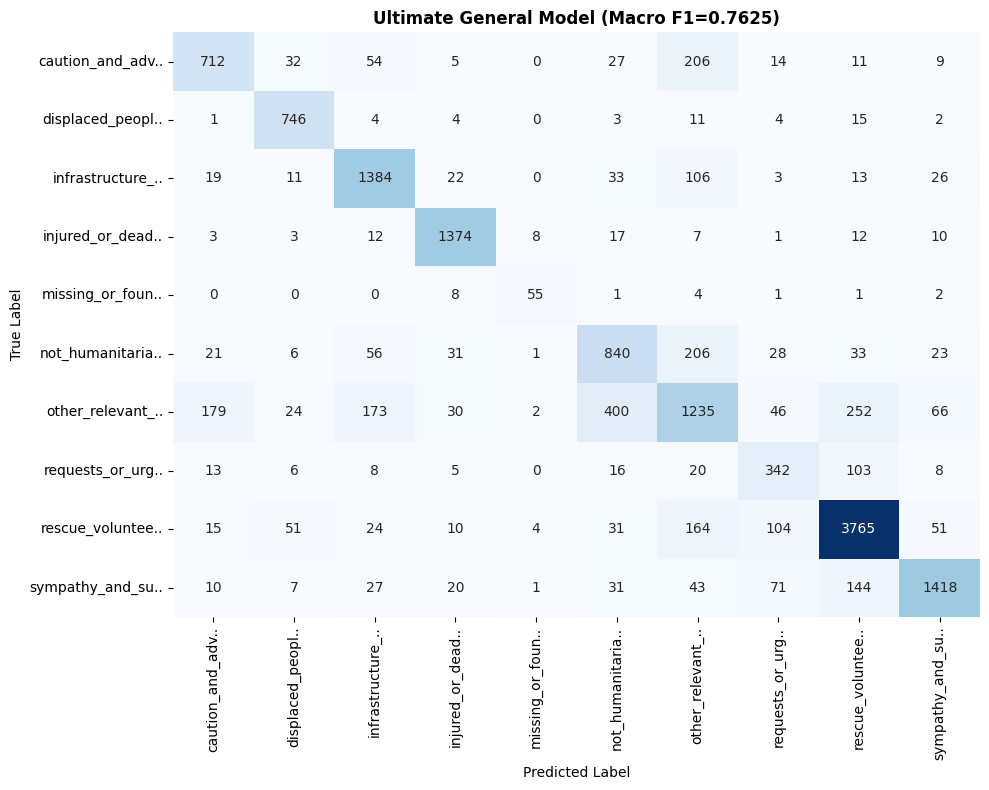

In [5]:
# ==========================================
# Section 5: Save General Model & Final Report
# ==========================================

# 1. Load the best state and perform final evaluation
best_state_dict = {k: v.to(DEVICE) for k, v in es.best_model_state.items()}
model.load_state_dict(best_state_dict)
model.eval()
y_probs, y_preds = [], []

with torch.no_grad():
    for batch in test_loader:
        with autocast():
            logits = model(batch['input_ids'].to(DEVICE), attention_mask=batch['attention_mask'].to(DEVICE)).logits
            y_probs.extend(torch.nn.functional.softmax(logits, dim=1).cpu().numpy())
            y_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            
y_probs = np.array(y_probs)
y_preds = np.array(y_preds)

acc = accuracy_score(y_test_idx, y_preds)
present_labels_test = np.unique(y_test_idx)
f1_macro = f1_score(y_test_idx, y_preds, labels=present_labels_test, average='macro', zero_division=0)
f1_weighted = f1_score(y_test_idx, y_preds, labels=present_labels_test, average='weighted', zero_division=0)

print("\n" + "="*60)
print(f"ULTIMATE GENERAL MODEL PERFORMANCE")
print("="*60)
print(f"Tested on 100% Combined Test Data (All 4 Disasters)")
print(f"Accuracy:    {acc:.4f}")
print(f"F1 Macro:    {f1_macro:.4f}")
print(f"F1 Weighted: {f1_weighted:.4f}")
print("="*60)

# 2. Save the Ultimate Model for the UI
save_dir = "saved_lora_models/lora_general_all_data"
os.makedirs(save_dir, exist_ok=True)
model.save_pretrained(save_dir)
print(f"\n[General Model Saved] LoRA weights saved to {save_dir}/")
print(f"The model is now ready to be deployed in your Gradio UI!")

# 3. Plot Confusion Matrix for the General Model
plt.figure(figsize=(10, 8))
short_names = [n[:15] + '..' if len(n) > 15 else n for n in label_encoder.classes_]
cm = confusion_matrix(y_test_idx, y_preds, labels=range(num_labels))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=short_names, yticklabels=short_names, cbar=False)
plt.title(f"Ultimate General Model (Macro F1={f1_macro:.4f})", fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()